In [1]:
%matplotlib widget

from Stochastic_Sampling import *


<center> <h1> STOCHASTIC SAMPLING </h1> 
<h3>Or</h3>
 <h3>Monte Carlo Methods </h3> </center>

<div style="text-align: right;">André van Schaik<br>April 2015<br>updated March 2023<br>extended April 2026</div>

This notebook was created by me to try and understand this material better and play with some of the concepts introduced below by running the code with different settings. Feel free to use this, but I don't know that everything that follows is without mistakes. Please let me know if you find any.

# Integral of a function

Say we are interested in estimating the integral of a function we cannot analytically calculate. (Note, the example below uses a function for which we can calculate the integral - a sum of two Gaussians - so we can compare with a ground truth.)

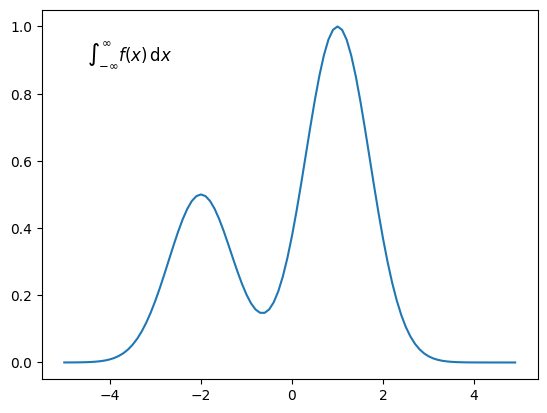

In [2]:
plot_integral_function();

A standard approach would be to sample the function at regular intervals and sum the appropriately weighted samples.

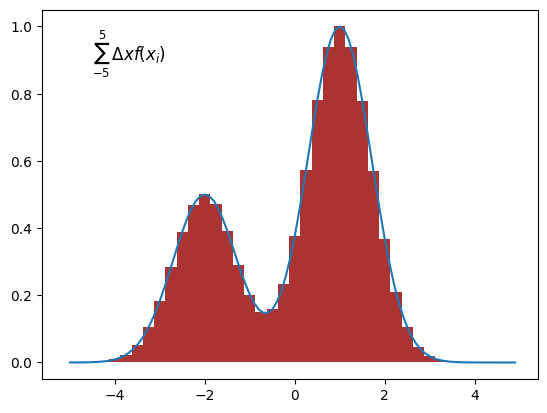

Value of Integral =  2.658680776358274
Approximation =  2.6586767988293474


In [3]:
plot_regular_sampling();

The weights of each bin are equal and are given by:

$$
\sum_{-5}^5 \Delta x \, f(x) = \frac{\mathrm{range}}{\mathrm{num\_bins}}\sum_{-5}^5 f(x)
$$ 

# Random (Uniform) Sampling
Instead of regular sampling, you can also pick your sample points uniformly distributed across the range of interest.

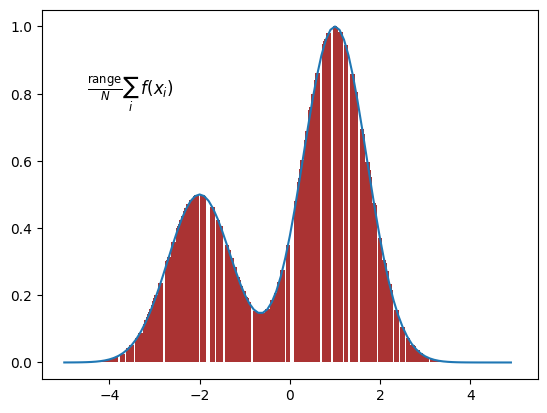

N = number of samples =  200
Value of Integral =  2.658680776358274
Approximation =  2.5703556308201643


In [4]:
plot_uniform_sampling();

### Note on the relation between discrete sampling and continuous distributions

If samples $x_i$ are distributed according to a pdf $p(x)$, then, by the definition of the Expected Value:

$$\text{E}(f(x)) = \int p(x)\,f(x)\,\mathrm{d}x \approx \frac{1}{N} \sum_i f(x_i)$$

Thus to evaluate our integral, we have:

$$\frac{\text{range}}{N} \sum_i f(x_i) \approx \text{range}\int_{-5}^5 p(x)\,f(x)\,\mathrm{d}x = \int_{-5}^5 \,f(x)\,\mathrm{d}x$$
$$\text{if} \quad p(x) = \frac{1}{\text{range}}$$

# Problem
Sometimes most samples from a uniform distribution are uninformative, because they sample values of $x$ where $f(x)$ is (nearly) 0.

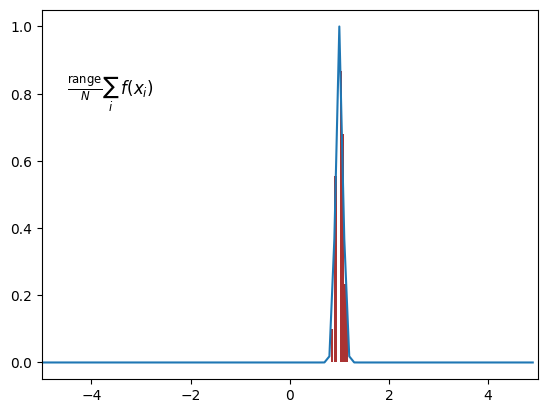

samples = 200
Value of Integral =  0.1772453850905516
Approximation =  0.16474084241522788


In [5]:
plot_narrow_function_uniform_sampling();

# Solution: Importance Sampling
Concentrate the samples in the region of interest, and correct the summation by assigning each sample an appropriate weight. This is called **Importance Sampling** and improves (reduces the variance of) your estimate. In the figure below the samples of $x$ are drawn from a probability distribution proportional to the red curve. You can see that the estimate of the value of the integral is not perfect, but much better than before. If you run the code a few times, you'll get an idea of the variance of the approximation.

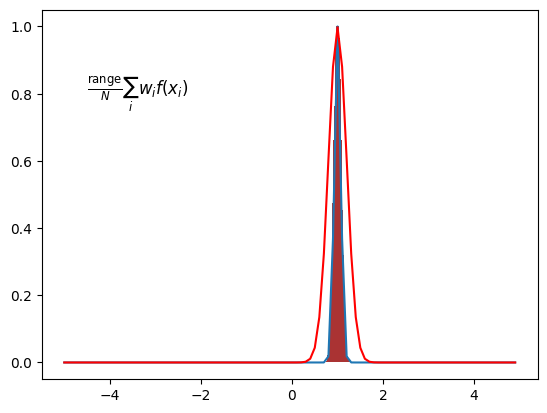

samples =  200
Value of Integral =  0.1772453850905516
Approximation =  0.1747250741307662


In [6]:
plot_importance_sampling();

### Finding the weights

As above, we start with the definition of the Expected Value and introduce the sample distribution $q(x)$:

$$\begin{align*}\int p(x)\,f(x)\,\mathrm{d}x &= \int \frac{p(x)}{q(x)}\,{q(x)}\,f(x)\,\mathrm{d}x \\ &= \int w\,{q(x)}\,f(x)\,\mathrm{d}x \\ &\approx \frac{1}{N} \sum_i w_i\,f(x_i) \quad \text{with: } w_i = \frac{p(x_i)}{q(x_i)} \text{and } x_i \text{ distributed according to } q(x).
\end{align*}$$

Note that for the problem setting above we are interested in the **integral** of $f(x)$, not the **Expected Value**. We get the integral according to: 

$$\begin{align*}
\frac{\text{range}}{N} \sum_i w_i\,f(x_i) &= \frac{\text{range}}{N} \sum_i \frac{p(x_i)}{q(x_i)}\,f(x_i)\\
&= \frac{\text{range}}{N} \sum_i \frac{1/\text{range}}{q(x_i)}\,f(x_i)\\
&= \frac{1}{N} \sum_i \frac{f(x_i)}{q(x_i)}
\end{align*}$$

In other words, you are simply weighting the function values evaluated at samples $x_i$ by how likely the sample $x_i$ is to be picked, given by $q(x_i)$.

# Ideal importance distribution
Ideally you concentrate the samples proportional to the function itself. If you can do this, any sample will do!

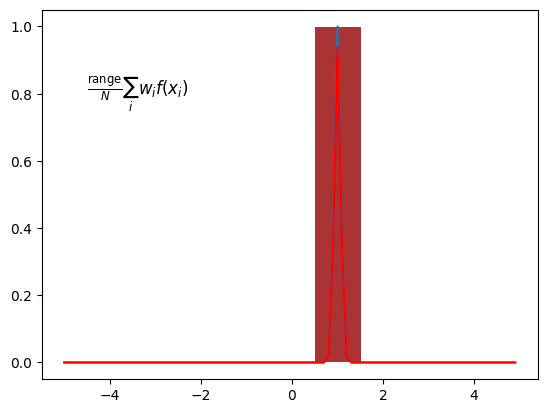

samples =  1
Value of Integral =  0.1772453850905516
Approximation =  0.17724538509055157


In [7]:
plot_ideal_importance_sampling();

# But how do you generate samples according to $f(x)$?

One way is to sample all the space and discard the samples above the curve. This is called **rejection sampling**, or **acceptance-rejection sampling**. 

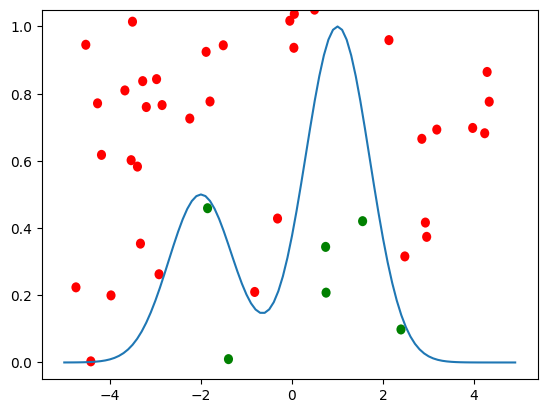

samples =  50


In [8]:
animate_rejection_sampling();

However, you can see that this is highly inefficient, particularly as the number of dimensions go up, as most of your samples will be discarded.

# The Metropolis Algorithm

The idea of Metropolis sampling is to generate the samples iteratively until you get a stable distribution of samples according to *f(x)*. Such iterative methods of generating samples from a distribution are called **Markov Chain Monte Carlo**.

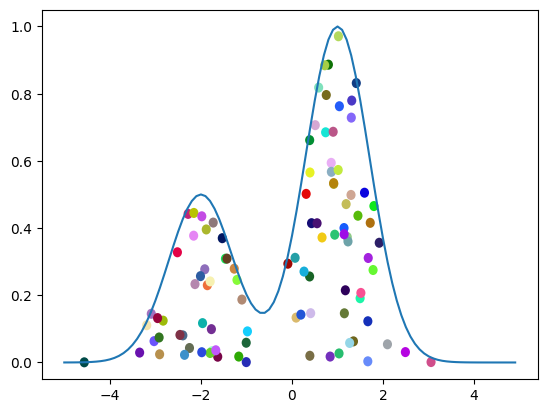

samples =  100


In [9]:
animate_metropolis_sampling();

# The Metropolis Algorithm Details

Each random initial sample $s$ has a distribution around it from which a new sample $s'$ is drawn, which is called the **proposal distribution**. If $f(s') > f(s)$, the new sample is kept and the old one discarded. If $f(s') < f(s)$, then the $s'$ is kept with a probability equal to $f(s') / f(s)$, and otherwise $s$ is kept.

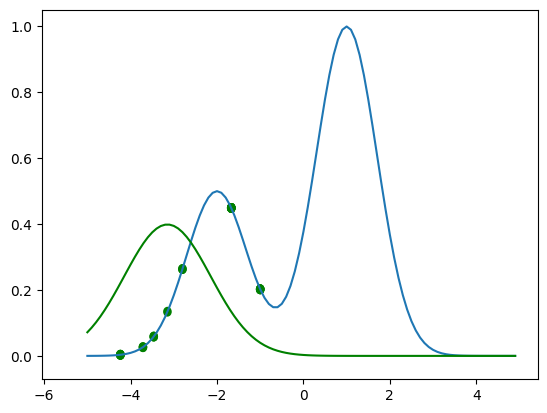

In [10]:
animate_single_chain_metropolis();

To obtain an intuition as to why this works, assume that the current sample is in a region where $f(x)$ has a monotone slope and assume the proposal distribution is narrow, so that only nearby samples are proposed. Then, the probability of proposing a sample with a higher value of $f(x)$: $p(x'\mid f(x')>f(x))= 0.5$ and the probability of accepting that sample is 1.

Similarly, $p(x'\mid f(x')<f(x))= 0.5$ and the probability of accepting that sample is $f(x')/f(x)$

If I generate a number samples from the current sample point, the ratio of samples with $f(x')<f(x)$ over $f(x')>f(x)$ is exactly $f(x')/f(x)$.

I am doing this at all points of the distribution, so since the ratios are all correct, the full set of samples will represent the distribution correctly. With a little reflection you can probably convince yourself that the argument also holds if the current sample is at a local maximum or minimum of the function.

One issue to keep in mind is that your proposal distribution should have support everywhere that the target distribution has support. If this is not the case, then your importance sampling estimator will be biased. For example, if your proposal distribution is a narrow Gaussian centered at 0, and your target distribution is a wider Gaussian centered at 0, then your importance sampling estimator will be biased because the proposal distribution does not have support for values far from 0. Or if your distribution has multiple local maxima, then it is easy to get stuck near one.

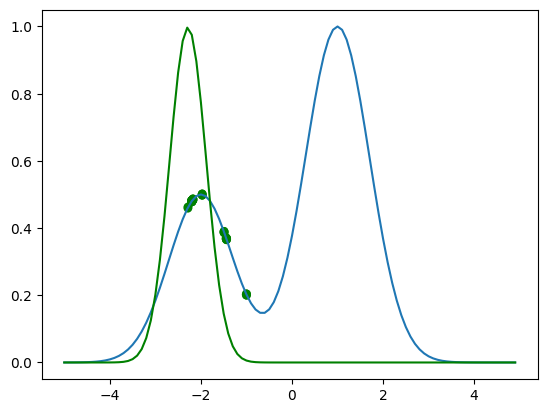

In [11]:
animate_single_chain_metropolis(sigma = 0.4, pause = 1.0);

# Metropolis-Hastings
Hastings proposed in 1970 a modification of the Metropolis algorithm that is now commonly used. It allows for an assymetric proposal distribution, and corrects the acceptance probability when $f(s') < f(s)$ with the ratio of the areas of either side of the proposal distribution. Here we use for illustration the normal distribution with an offset, but in practice it allows smarter proposal distributions to be used.

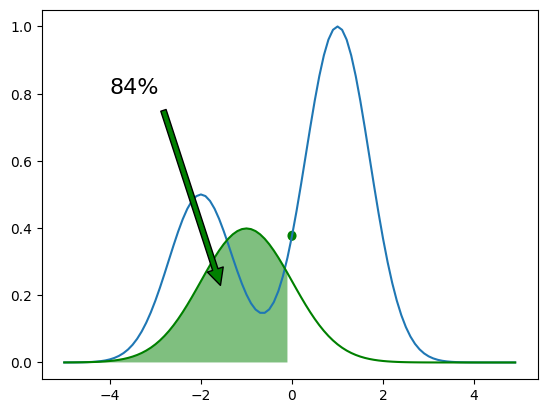

In [12]:
plot_metropolis_hastings_bias();

$p(x'\mid x'>x)= 0.16$ and $p(x'\mid x'<x)= 0.84$

So if $x'>x$, accept a sample with $f(x')<f(x)$ with probability: 

$$\frac{0.84 \times f(x')}{0.16 \times f(x)}$$

If $x'<x$, accept a sample with $f(x')<f(x)$ with probability: 

$$\frac{0.16 \times f(x')}{0.84 \times f(x)}$$

If $f(x')>f(x)$ always accept $x'$ as before.

In general, if the probability of proposing new sample $x'$ given a current sample $x$ for is given by $q(x'|x)$, then the acceptance probability of $x'$ under **Metropolis-Hastings** is given by:

$$\text{min}\left\{1,\frac{f(x')/q(x'|x)} {f(x)/q(x|x')}\right\} = \text{min}\left\{1,\frac{f(x')q(x|x')}{f(x)q(x'|x)}\right\} $$

# Gibbs sampling

If $x$ is a vector with more than one element, instead of sampling from the full joint distribution using an appropriate proposal distribution, it can be simpler to sample from the marginal distribution of each element in turn. This is called **Gibbs sampling**.

In this case $x'$ is identical to $x$ except for its value along the $i^\text{th}$ dimension, which is sampled from the conditional distribution $p(x_i|x_{-i})$ where $x_{-i} = \{x_1, ..., x_{i-1}, x_{i+1}, ..., x_n\}$. This leads to the proposal of $x'$ always being accepted, because:

$$ \begin{align*}
\frac{p(x')}{p(x)}\frac{q(x|x')}{q(x'|x)} 
&= \frac{p(x'_i|x'_{-i})p(x'_{-i})}{p(x_i|x_{-i})p(x_{-i})}\frac{p(x_i|x'_{-i})}{p(x'_i|x_{-i})}\\
&= \frac{p(x'_i|x_{-i})p(x_{-i})}{p(x_i|x_{-i})p(x_{-i})}\frac{p(x_i|x_{-i})}{p(x'_i|x_{-i})}\\ 
&= \frac{p(x_{-i})}{p(x_{-i})}\\ 
&= 1
\end{align*} $$

since $x'_{-i} = x_{-i}$ as we don't change any values along those dimensions at this step.

# So why do we care?

**Inference from data!**

Say we have a time series of text messages by a user as shown below. 
<div style="font-size: 100%;">(Example and some of the text taken from the excellent iPython notebook <a href="http://camdavidsonpilon.github.io/Probabilistic-Programming-and-Bayesian-Methods-for-Hackers/" Bayesian Methods for Hackers>Bayesian Methods for Hackers</a> by Cam Davidson-Pilon)</div>

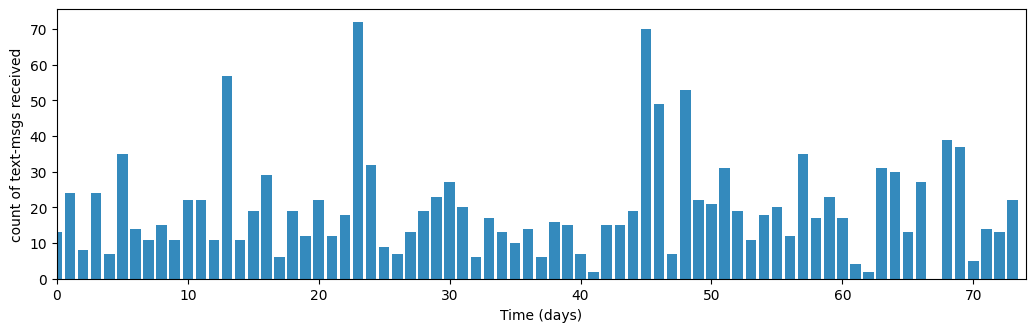

In [13]:
_, count_data = plot_count_data()
n_count_data = len(count_data)

Looking at this, we suspect that there might be a higher rate of texting in the second part of the series. To quantify this, we should infer the rate in the first part of the series, and the rate in the second part of the series, as well as the point of change. If the two rates come out nearly the same, we would be uncertain that there was an actual change.

How can we start to model this? This type of count data is typically modelled as a Poisson process. Denoting day $i$'s text-message count by $C_i$, 

$$
C_i \sim \text{Poisson}(\lambda)
$$  

with

$$
\lambda = 
\begin{cases}
\lambda_1  & \text{if } t \lt \tau \cr
\lambda_2 & \text{if } t \ge \tau
\end{cases}
$$



# Baysian Inference

The joint probability for a set of observations $O$ and the underlying variables of a model $V$ is given by:

$$ P( V , O ) = P( V | O ) P(O) = P(O | V) P(V) $$

Or, we can write this as **"Bayes' Rule"**:

$$ P( V | O ) = \frac{ P(O | V) P(V) } {P(O) } \propto P(O | V) P(V)$$

So in order to work out the likely values of the variables in our model, we can use the Poisson model above determine $P(O | V)$ but we will also need to assign prior distributions $P(V)$ to each of our variables. Typically the full distribution of possible observations is unknown, but we don't need this for MCMC. Using MCMC we can sample variables from their assumed prior distributions. Next we can propagate these samples according to appropriate proposal distributions, and calculate the likelihood of these variables given the observations and use these to decide to keep or discard the new samples (variables) according to the Metropolis-Hastings algorithm. Luckily there are tools, such as PyMC in Python, that not only take care of the sampling for us, but also automatically pick the most appropriate proposal distribution.

# Hyperparameters

So, what would be good prior probability distributions for $\lambda_1$ and $\lambda_2$?  $\lambda$ can be any positive number and the *exponential* distribution provides a continuous density function for positive numbers and might be a good choice for modelling $\lambda_i$. But the exponential distribution takes a parameter of its own, so we'll need to include that parameter in our model. Let's call that parameter $\alpha$.

\begin{align*}
&\lambda_1 \sim \text{Exp}( \alpha ) \\\
&\lambda_2 \sim \text{Exp}( \alpha )
\end{align*}

$\alpha$ is called a **hyper-parameter** or **parent variable**. In literal terms, it is a parameter that influences other parameters. 

Our initial guess at $\alpha$ does not influence the model too strongly, so we have some flexibility in our choice. Since we're modelling $\lambda$ using an exponential distribution, we can use the expected value to set $\alpha$:

$$
\frac{1}{N}\sum_{i=0}^N \;C_i \approx E[\; \lambda \; |\; \alpha ] = \frac{1}{\alpha}
$$ 

What about $\tau$? Because of the noisiness of the data, it's difficult to pick out a priori when $\tau$ might have occurred. Instead, we can assign a *uniform prior belief* to every possible day. This is equivalent to saying:

\begin{align*}
& \tau \sim \text{DiscreteUniform(1,70) }\\\\
& \Rightarrow P( \tau_i ) = \frac{1}{70}
\end{align*}

# ... and what do we get?

You will need to have the **pymc** package installed to run the code below. If you do, you can replace the exponential prior for $\lambda$ with a uniform one, by calling `run_single_change_mcmc(count_data, dist = 'uniform')` below instead. You will notice that it makes very little difference in the estimates for the model parameters.

In [14]:
single_change_results = run_single_change_mcmc(count_data)
# single_change_results_uniform = run_single_change_mcmc(count_data, dist='uniform')
lambda_1_samples = single_change_results["lambda_1_samples"]
lambda_2_samples = single_change_results["lambda_2_samples"]
tau_samples = single_change_results["tau_samples"]

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [lambda_1]
>Metropolis: [lambda_2]
>Metropolis: [tau]


Output()

Sampling 4 chains for 5_000 tune and 10_000 draw iterations (20_000 + 40_000 draws total) took 3 seconds.


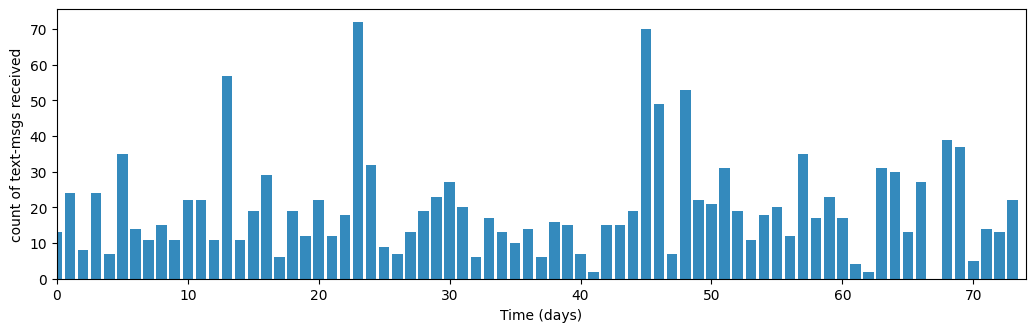

In [15]:
plot_count_data();

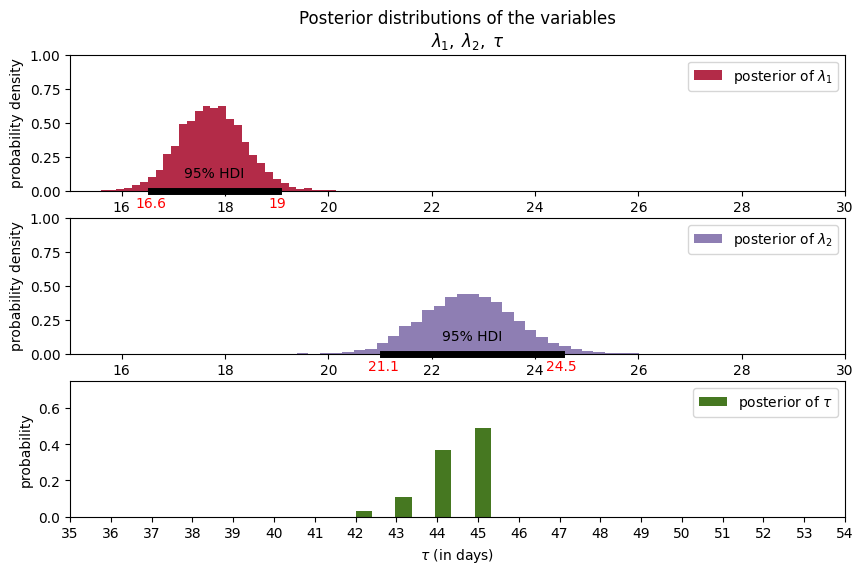

In [16]:
plot_single_change_posteriors(lambda_1_samples, lambda_2_samples, tau_samples, n_count_data);

# Or are there three sections?

In the section above, we are inferring when the rate changes, but we are also arbitrarily assuming that there is only one change in rate. We could also assume there is a middle section with a lower rate than the early or later days. This is an important thing to note: you only get answers about the model you are proposing, not about any other possible models that might explain the data.

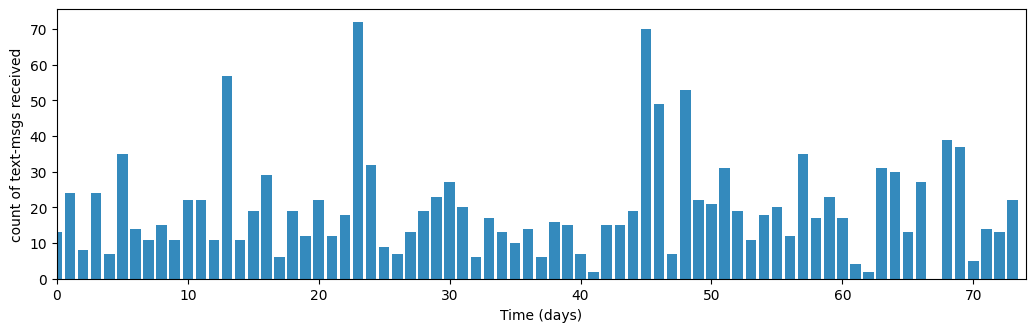

In [17]:
plot_count_data();

(Note, the code below doesn't always give reasonable answers. You could have the two switch points really close to each other, which would not give you enough data for one of the distributions. I cheat a little below by forcing the prior for $\tau_1$ to be uniform between day 20 and 30, and for $\tau_2$ uniform between day 40 and the end of the series and by picking a random seed that seems to work on my machine. There probably isn't sufficient data to decide on this and the sampling below might throw some errors or warnings. But running the MCMC cell below followed by the plotting code a few times usually works.)

In [18]:
three_segment_results = run_three_segment_mcmc(count_data, seed=100)
lambda_1_samples = three_segment_results["lambda_1_samples"]
lambda_2_samples = three_segment_results["lambda_2_samples"]
lambda_3_samples = three_segment_results["lambda_3_samples"]
tau_1_samples = three_segment_results["tau_1_samples"]
tau_2_samples = three_segment_results["tau_2_samples"]

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [lambda_1]
>Metropolis: [lambda_2]
>Metropolis: [lambda_3]
>Metropolis: [tau_1]
>Metropolis: [tau_2]


Output()

Sampling 4 chains for 5_000 tune and 10_000 draw iterations (20_000 + 40_000 draws total) took 4 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


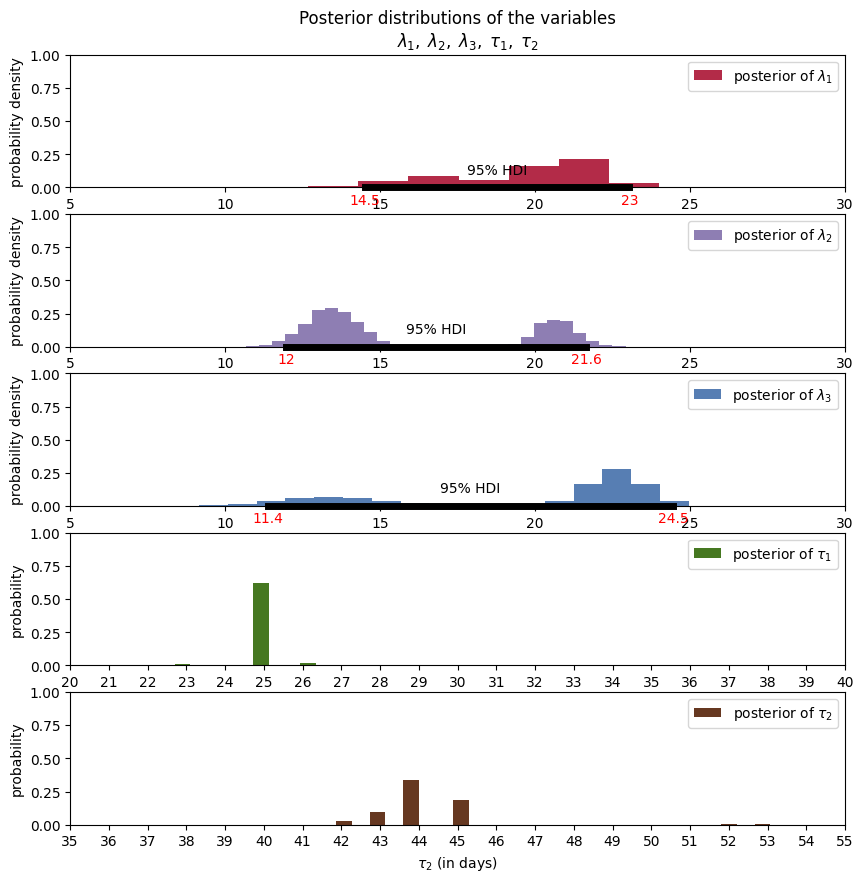

In [19]:
plot_three_segment_posteriors(lambda_1_samples, lambda_2_samples, lambda_3_samples, tau_1_samples, tau_2_samples, n_count_data);

---
# (Nonlinear) Dynamical Systems

The previous slides have all been about estimating static distributions (and integrals). Even though the example above used data from a timeseries, we already had the data for the whole time we were considering and therefore we were working with a static distribution.

Now consider the following system, which is a **Hidden Markov Model**, where we obtain a new observation, according to a known observation function $g(y_t|x_t)$ every time step, but the underlying hidden state that causes the observations now varies with time according to a transition function $f(x_t|x_{t-1})$. The typical assumption is that the observations are conditionally independent. In other words, observation $y_t$ only depends on state $x_t$, not on earlier states.

$$P(y_{0:t} | x_{0:t}^{(i)}) = \prod_{s=0}^t P(y_s | x_s^{(i)})$$


<center><img src='HMM.png', width=80%></center>

(This part of the notebook was written after reading O. Cappe, S. J. Godsill, and E. Moulines, “An Overview of Existing Methods and Recent Advances in Sequential Monte Carlo,” *Proceedings of the IEEE*, vol. 95, no. 5, pp. 899–924, May 2007. The figure above is a copy of their Figure 1 and used here for educational purposes.)

## Bayesian Recursion

The joint probability distribution of the state variables over time $t$ according to Bayes' Rule is given by the recursion:

$$\begin{align*}
 P( x_{0:t} | y_{0:t} ) &\propto P(y_t | x_t)\; P(x_{0:t}|y_{0:t-1}) \\
 &\propto g(y_t | x_t)\; f(x_t|x_{t-1})\; P(x_{0:t-1}|y_{0:t-1})
\end{align*}$$

If, given a state $x_t$ we know the transition probability $f(x_{t+1}|x_{t})$ and the observation probability $g(y_t|x_t)$, we can iterate through this recursion if we can generate samples distributed according to $P(x_{0:t-1}|y_{0:t-1})$. This is not always possible, so we can repeatedly apply the same trick as in **importance sampling**. This is then called **sequential importance sampling**.

## Sequential Importance Sampling

For this we generate samples from a conveniently chosen proposal distribution $Q(x_{0:t}|y_{0:t})$ and then calculate the unnormalised importance weights according to:

$$\tilde{w}_t^{(i)} = P(x_{0:t}^{(i)}|y_{0:t})/Q(x_{0:t}^{(i)}|y_{0:t})$$

which can be normalised by dividing by $\sum_i\,\tilde{w}_t^{(i)}$ when needed.
The trick is to choose the importance distribution such that it factorises in a form similar to that of the target posterior distribution:

$$Q(x_{0:t}|y_{0:t}) = Q(x_{0:t-1}|y_{0:t-1})Q(x_t|x_{t-1},y_t)$$

The weights then take the form:

$$\begin{align*}
\tilde{w}_t^{(i)} &= P(x_{0:t}^{(i)}|y_{0:t})/Q(x_{0:t}^{(i)}|y_{0:t})\\
&\propto \tilde{w}_{t-1}^{(i)} \times \frac{g(y_t | x_t)\; f(x_t|x_{t-1})}{Q(x_t|x_{t-1},y_t)}
\end{align*}$$

This is typically calculated in log space to make it more numerically simple and stable:
$$\log w_t^{(i)} \propto \sum_{s=0}^t \log P(y_s | x_s^{(i)})$$


## ... but it doesn't really work!

While sequential importance sampling works for short runs, it fails for longer runs due to an effect known as weight **degeneracy**, meaning that a small proportion of the weights contain nearly all of the probability mass and most samples contribute nothing significant to the estimates.

Part of the problem is that we are estimating $ P_{0:t}( x_{0:t} | y_{0:t} )$, i.e., the joint distribution at all times, so that each observation the number of dimensions grows by the number of state variables. This is bound to fail as we ultimately won't have enough information.

## Weight Degeneracy in Sequential Importance Sampling

Let's see this weight degeneracy in action with a simple example. Consider a 1D random walk where the true state follows $x_t = x_{t-1} + \epsilon_t$ with $\epsilon_t \sim \mathcal{N}(0, 0.5^2)$, and we observe $y_t = x_t + \nu_t$ with $\nu_t \sim \mathcal{N}(0, 1^2)$. We'll use a simple proposal distribution that just propagates particles forward with the transition model, ignoring the observations.

$$
x_0 \sim \mathcal{N}(0, 1^2),
$$

$$
x_t \mid x_{t-1} \sim \mathcal{N}(x_{t-1}, \sigma_{\mathrm{proc}}^2),
$$

$$
y_t \mid x_t \sim \mathcal{N}(x_t, \sigma_{\mathrm{obs}}^2).
$$

#### *Sidenote - feel free to skip* ####
*In this example both the transition density and observation density are Gaussian, and the state enters both equations linearly. Therefore every conditional distribution in the Bayesian recursion remains Gaussian. That means the posterior can be computed **exactly**, without approximation, by propagating only means and variances. We do this so that we can compare the result obtained with Sequential Importance Sampling directly to the exact solution.*

*To calculate the exact solution, the forward Bayesian recursion is:*

$$
p(x_t \mid y_{0:t-1}) = \int p(x_t \mid x_{t-1})\, p(x_{t-1} \mid y_{0:t-1})\, dx_{t-1},
$$

$$
p(x_t \mid y_{0:t}) \propto p(y_t \mid x_t)\, p(x_t \mid y_{0:t-1}).
$$

*And*

$$
p(x_{t-1} \mid y_{0:t-1}) = \mathcal{N}(m_{t-1}, P_{t-1}),
$$

*We can then use a **Kalman filter** to estimate this directly. The prediction step gives:*

$$
m_{t\mid t-1} = m_{t-1}, \qquad P_{t\mid t-1} = P_{t-1} + \sigma_{\mathrm{proc}}^2,
$$

*and the update step gives:*

$$
K_t = \frac{P_{t\mid t-1}}{P_{t\mid t-1} + \sigma_{\mathrm{obs}}^2},
$$

$$
m_t = m_{t\mid t-1} + K_t\bigl(y_t - m_{t\mid t-1}\bigr), \qquad P_t = (1-K_t)P_{t\mid t-1}.
$$

*So the filter computes the exact **filtering posterior** $p(x_t \mid y_{0:t})$.*


*To estimate the **full posterior** over past states, we then apply the **Rauch-Tung-Striebel smoother** backward in time. If $m_t, P_t$ are the filtering moments and $m_{t+1\mid t}, P_{t+1\mid t}$ are the one-step predictions, then the smoother gain is*

$$
G_t = \frac{P_t}{P_{t+1\mid t}},
$$

*and the backward recursion is*

$$
m_t^{\mathrm{smooth}} = m_t + G_t\bigl(m_{t+1}^{\mathrm{smooth}} - m_{t+1\mid t}\bigr),
$$

$$
P_t^{\mathrm{smooth}} = P_t + G_t^2\bigl(P_{t+1}^{\mathrm{smooth}} - P_{t+1\mid t}\bigr).
$$

*Therefore, in this model the Kalman smoother is not just a good approximation: it gives the exact Gaussian posterior $p(x_{0:t} \mid y_{0:t})$. That is why we can use it as the ground-truth benchmark when comparing the particle filter estimates.*

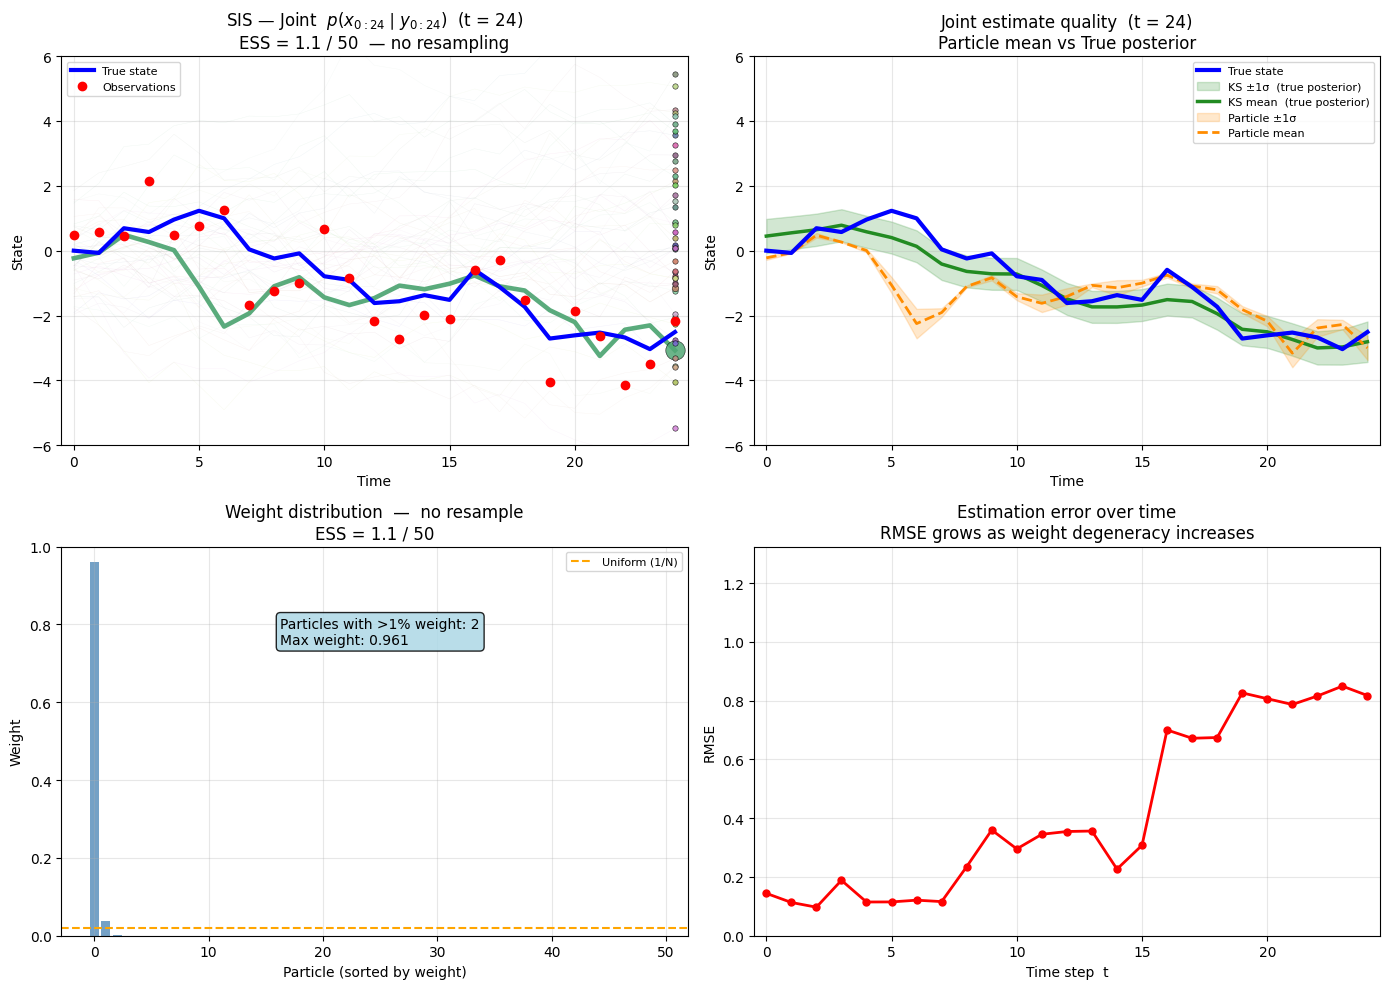

In [20]:
animate_sis_joint_demo();

## SIS with the Optimal Proposal  $Q(x_t | x_{t-1}, y_t)$

In the previous example we used a very simple proposal distribution that just propagated the state $x_t$ forward in time according to the transition model without taking the observations $y_t$ into account. For the linear-Gaussian model we can use the optimal proposal distribution instead, which integrates out $x_t$ analytically:

$$Q(x_t \mid x_{t-1}^{(i)}, y_t) = \mathcal{N}\!\left(\mu_t^{(i)},\, \sigma_\mathrm{opt}^2\right)$$

$$\sigma_\mathrm{opt}^2 = \left(\frac{1}{\sigma_\mathrm{proc}^2} + \frac{1}{\sigma_\mathrm{obs}^2}\right)^{-1}, \qquad \mu_t^{(i)} = \sigma_\mathrm{opt}^2\left(\frac{x_{t-1}^{(i)}}{\sigma_\mathrm{proc}^2} + \frac{y_t}{\sigma_\mathrm{obs}^2}\right)$$

Because the proposal already accounts for $y_t$, the incremental weight simplifies to the **predictive likelihood** (no $x_t$ needed):

$$w_t^{(i)} \;\propto\; w_{t-1}^{(i)} \cdot p(y_t \mid x_{t-1}^{(i)}) = w_{t-1}^{(i)} \cdot \mathcal{N}(y_t;\, x_{t-1}^{(i)},\, \sigma_\mathrm{proc}^2 + \sigma_\mathrm{obs}^2)$$

This is the best possible single-step variance reduction — compare the ESS decay with the prior-proposal version above.

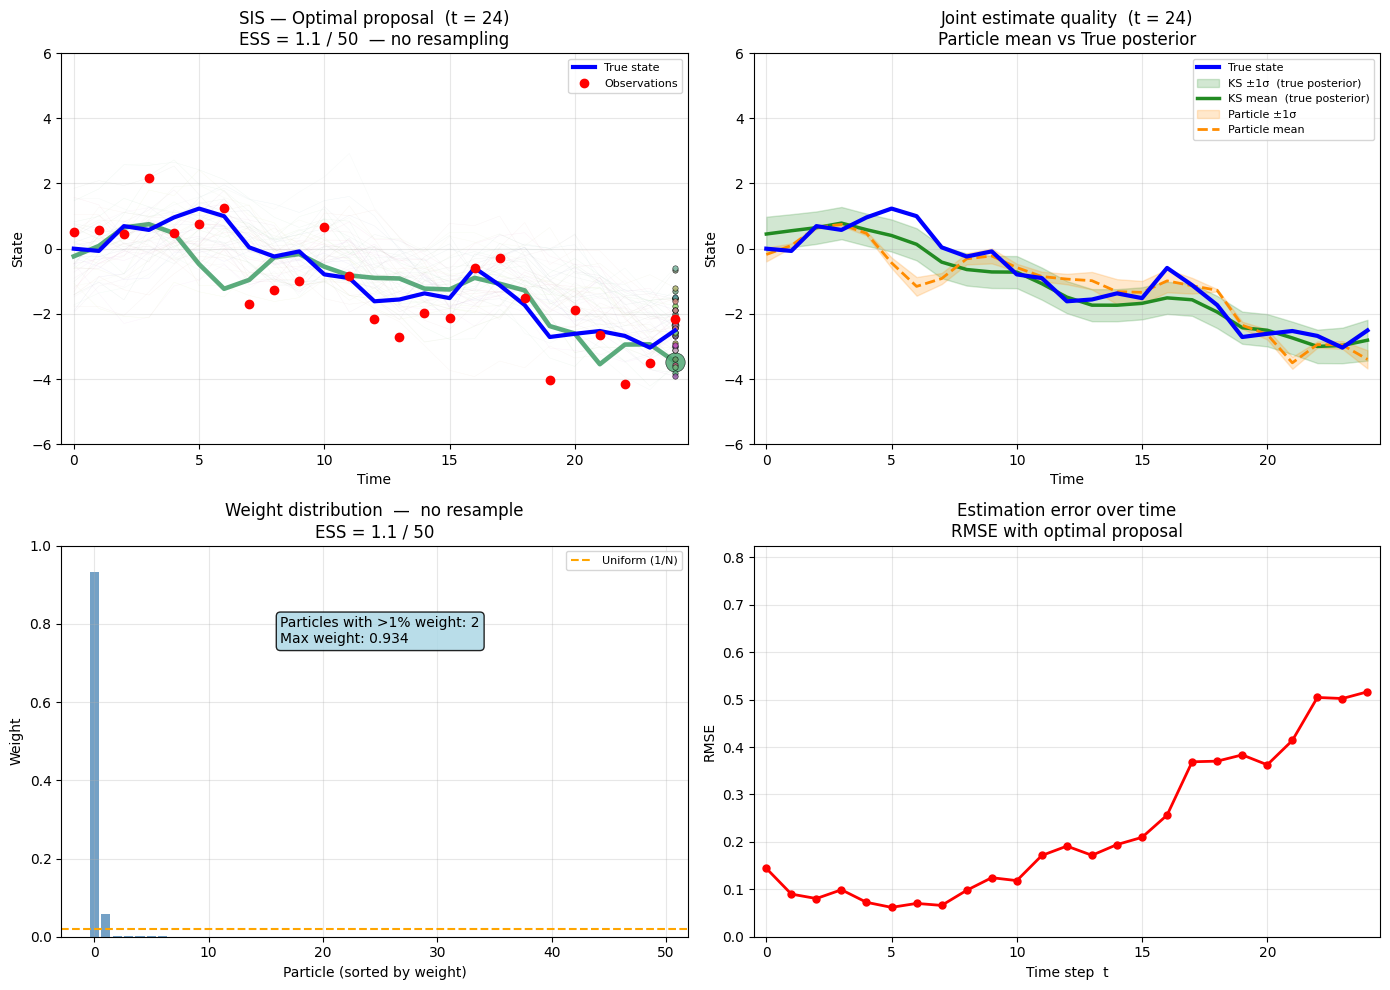

In [21]:
animate_sis_optimal_joint_demo();

## Systematic Resampling

In the examples above, the effective sample size reduces over time which causes the estimation error to increase. Resampling breaks this degeneracy cycle by periodically pruning low-weight particles and duplicating high-weight ones, followed by resetting all weights to $1/N$.

Particle filters use the **Systematic Resampling** algorithm to do this. Given normalised weights $\{w_t^{(i)}\}_{i=1}^N$:

1. Form the CDF: $C_k = \sum_{i=1}^k w_t^{(i)}$
2. Draw a single uniform offset: $u_1 \sim \mathcal{U}[0,\, 1/N]$
3. For each $j = 1,\ldots,N$ set $u_j = u_1 + (j-1)/N$
4. Select ancestor index $a_j = \min\{k : C_k \geq u_j\}$
5. Set $\tilde x_t^{(j)} = x_t^{(a_j)}$ and $\tilde w_t^{(j)} = 1/N$

This single sweep costs $O(N)$ and ensures all $N$ draws are spread evenly across the CDF — lower variance than multinomial resampling.

Resampling every step wastes diversity; doing it infrequent leads to degeneracy.  A common trigger is to resample when $\hat N_\text{eff} = \bigl(\sum_i (w_t^{(i)})^2\bigr)^{-1} < N/2$.

After resampling, some particle **lineages are duplicated** and others are discarded. In the trajectory plot below you can see paths collapsing together at each resampling event — this is *sample impoverishment*, a price paid for maintaining diversity in weights.

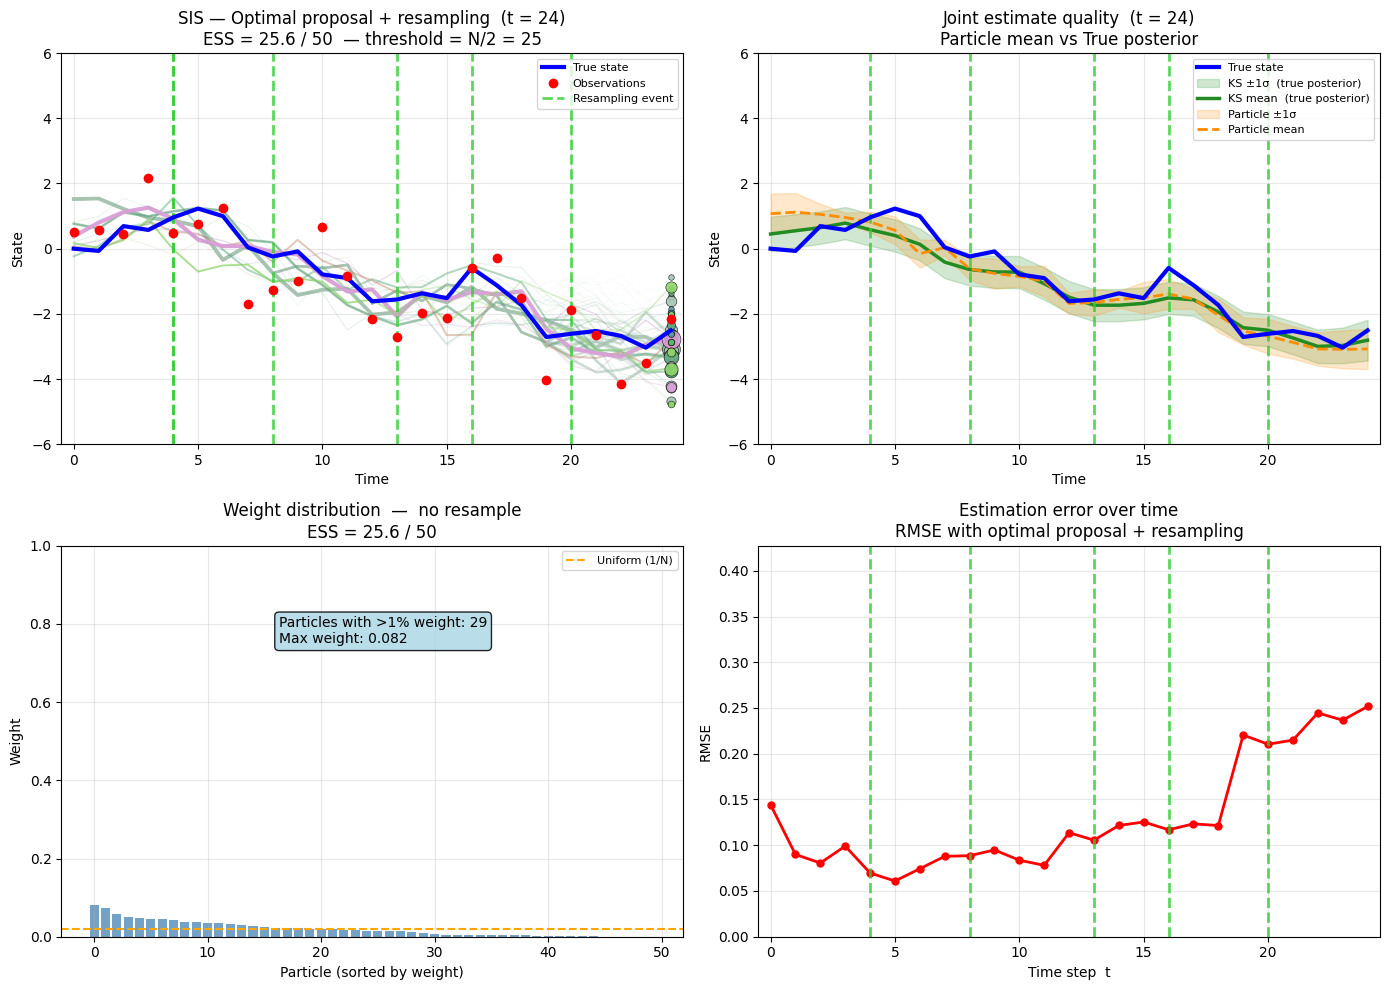


Resampling occurred at timesteps: [4, 8, 13, 16, 20]
Final ESS: 25.6 / 50


In [22]:
animate_optimal_resampling_demo();

In the example above we see that this works pretty well, with the distribution estimated from Sequential Importance Sampling closely matching the true posterior.

For completeness, we also apply Systematic Resampling to the case where we use the proposal distribution that is only based on the prior distribution of $x_t$, ignoring observations $y_t$. You will note that we need to resample more often with this non-optimal proposal distribution, resulting in a larger estimation error.

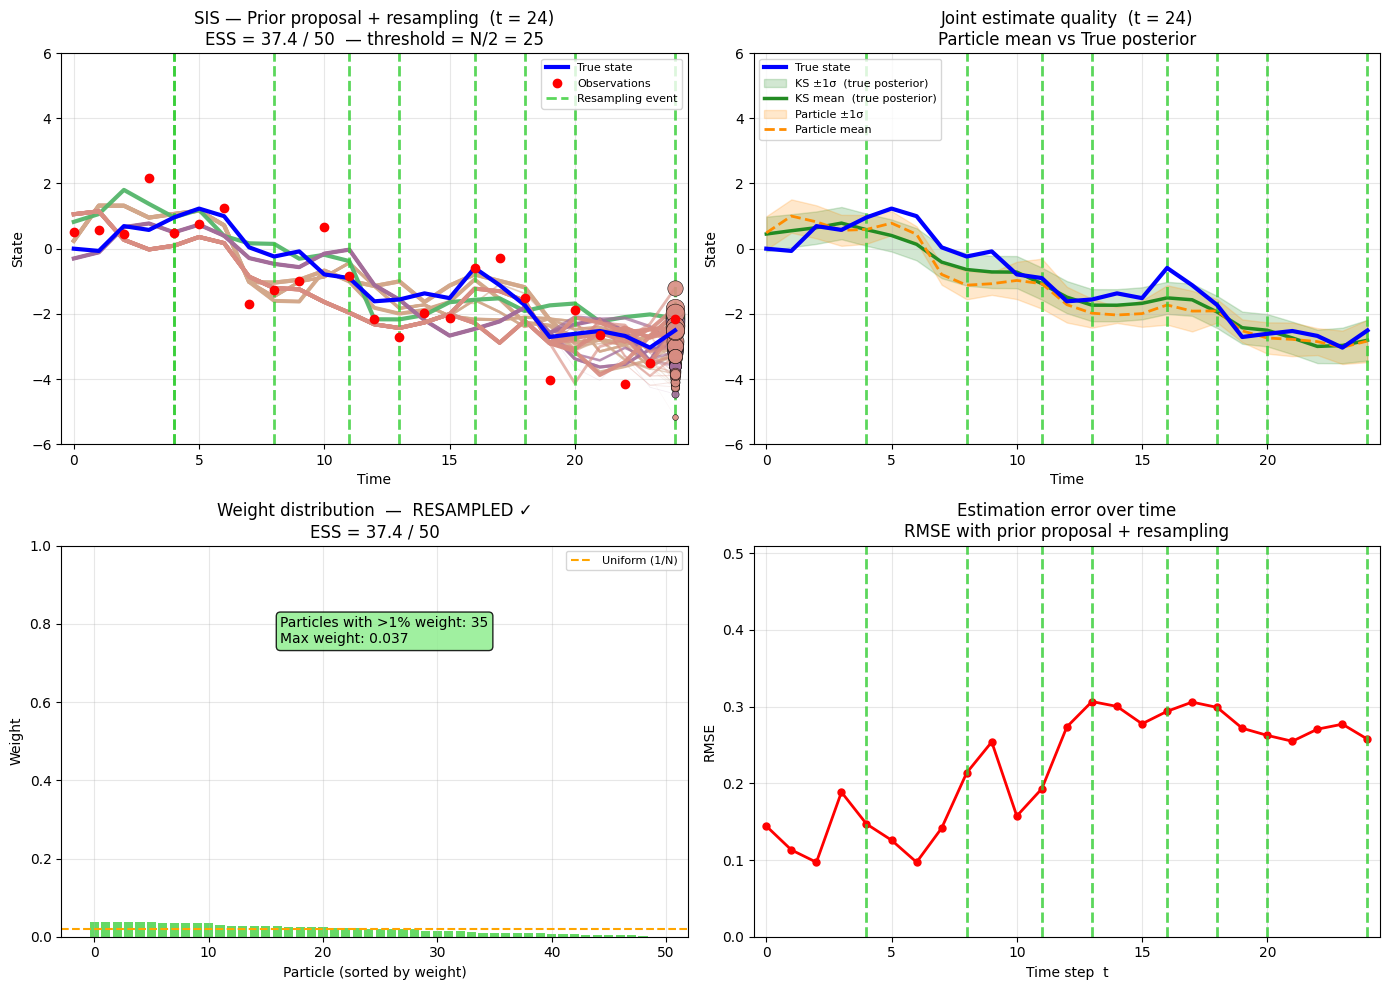


Resampling occurred at timesteps: [4, 8, 11, 13, 16, 18, 20, 24]
Final ESS: 37.4 / 50


In [23]:
animate_prior_resampling_demo();

## High-Dimensional State Space — Curse of Dimensionality in the Likelihood

The previous example tracked a **1-dimensional** state. Now consider a **d-dimensional** state space:

$$x_t = x_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,\, \sigma_\text{proc}^2 \mathbf{I}_d)$$
$$y_t = x_t + \nu_t, \quad \nu_t \sim \mathcal{N}(0,\, \sigma_\text{obs}^2 \mathbf{I}_d)$$

Each dimension is independent, so the likelihood factorises:

$$p(y_t \mid x_t^i) = \prod_{k=1}^{d} \mathcal{N}(y_t^k;\, x_t^{i,k},\, \sigma_\text{obs}^2)$$

This product is the source of the curse: each extra dimension multiplies a number typically **less than 1** into the weight, so weights collapse exponentially faster in $d$. With 50 particles and $d=8$ the ESS will hit the resampling threshold at nearly every step, producing many more resampling events than the 1D case.

Because the dimensions decouple, the exact posterior is still tractable — it is just $d$ independent 1D Kalman smoothers. This lets us continue to use the same KS gold standard for comparison. Below we have a 4 dimensional state and independent observations for each state. We are only plotting dimension 0, but you can try the other 3 dimensions by changing the value of `plot_d` in the function call.

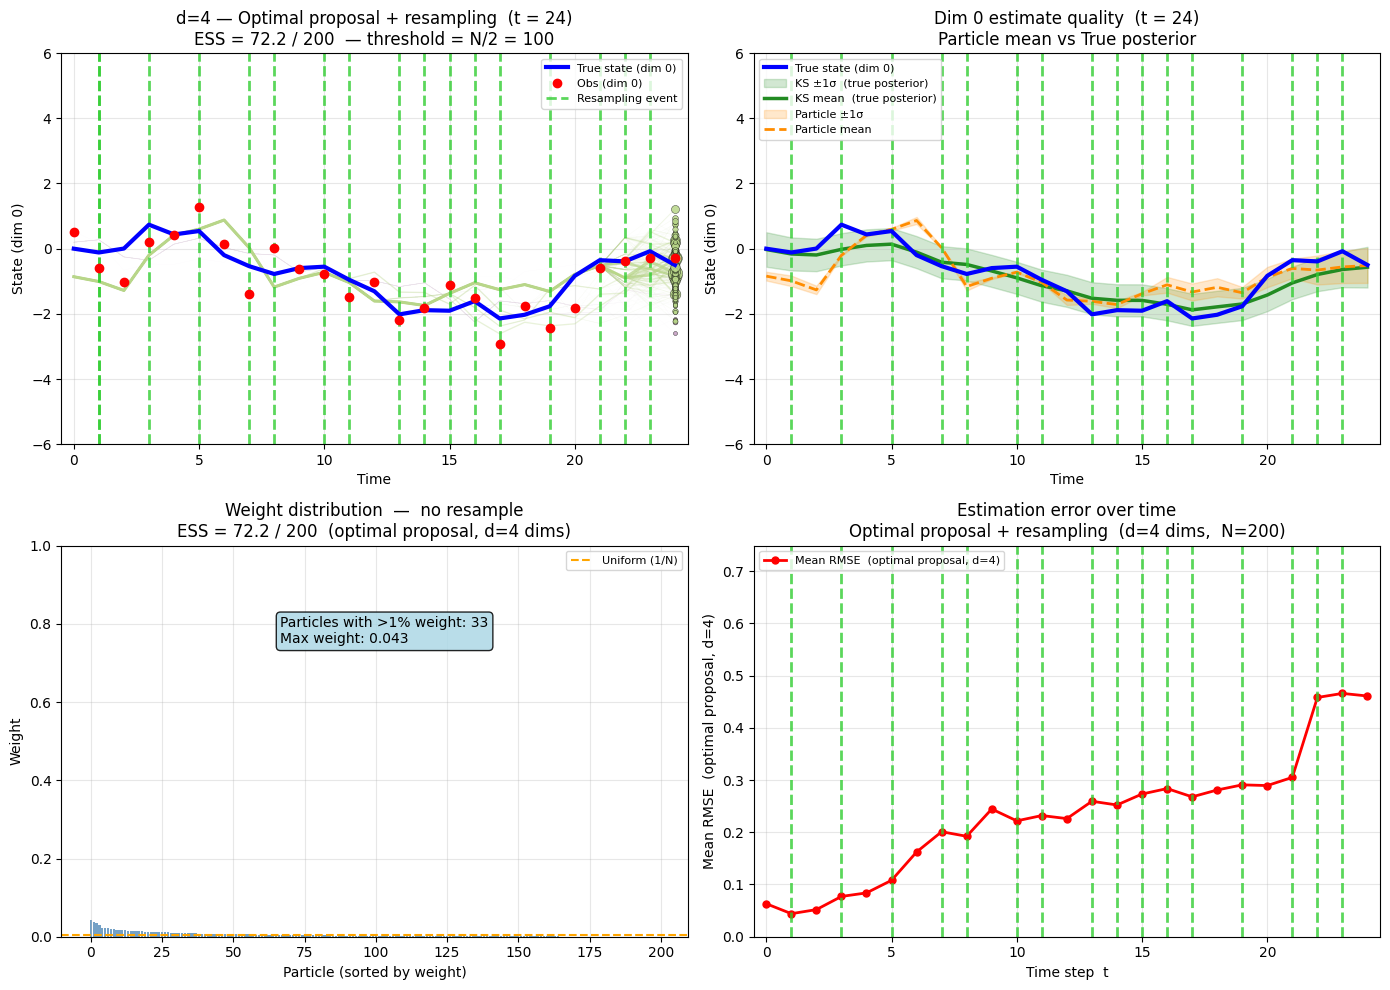


d=4, N=200: Resampling at timesteps: [1, 3, 5, 7, 8, 10, 11, 13, 14, 15, 16, 17, 19, 21, 22, 23]
Total resampling events: 16
Final ESS: 72.2 / 200


In [24]:
animate_high_dim_optimal_resampling(d = 4, plot_d = 0);

## Filtering Distribution vs Joint Distribution

The cell above estimates the **joint (smoothing) distribution** $p(x_{0:t} \mid y_{0:t})$: every particle carries its full trajectory via `lineage`, and the comparison target is the Kalman **smoother** over $0, \ldots, t$.

Often in online inference, we care only about the **filtering distribution** $p(x_t \mid y_{0:t})$ — the marginal over the *current* state only:

- **No trajectory tracking**: particles are propagated and reweighted at each step; only the current positions are kept.  
- **Gold standard**: the Kalman *filter* mean and variance at time $t$.  
- **RMSE**: particle filtering mean vs KF mean at the current time step (averaged over dimensions).

Because the filtering distribution discards past trajectory information, it requires far less memory ($O(N \cdot d)$ vs $O(N \cdot t \cdot d)$) and is the natural target for online inference.

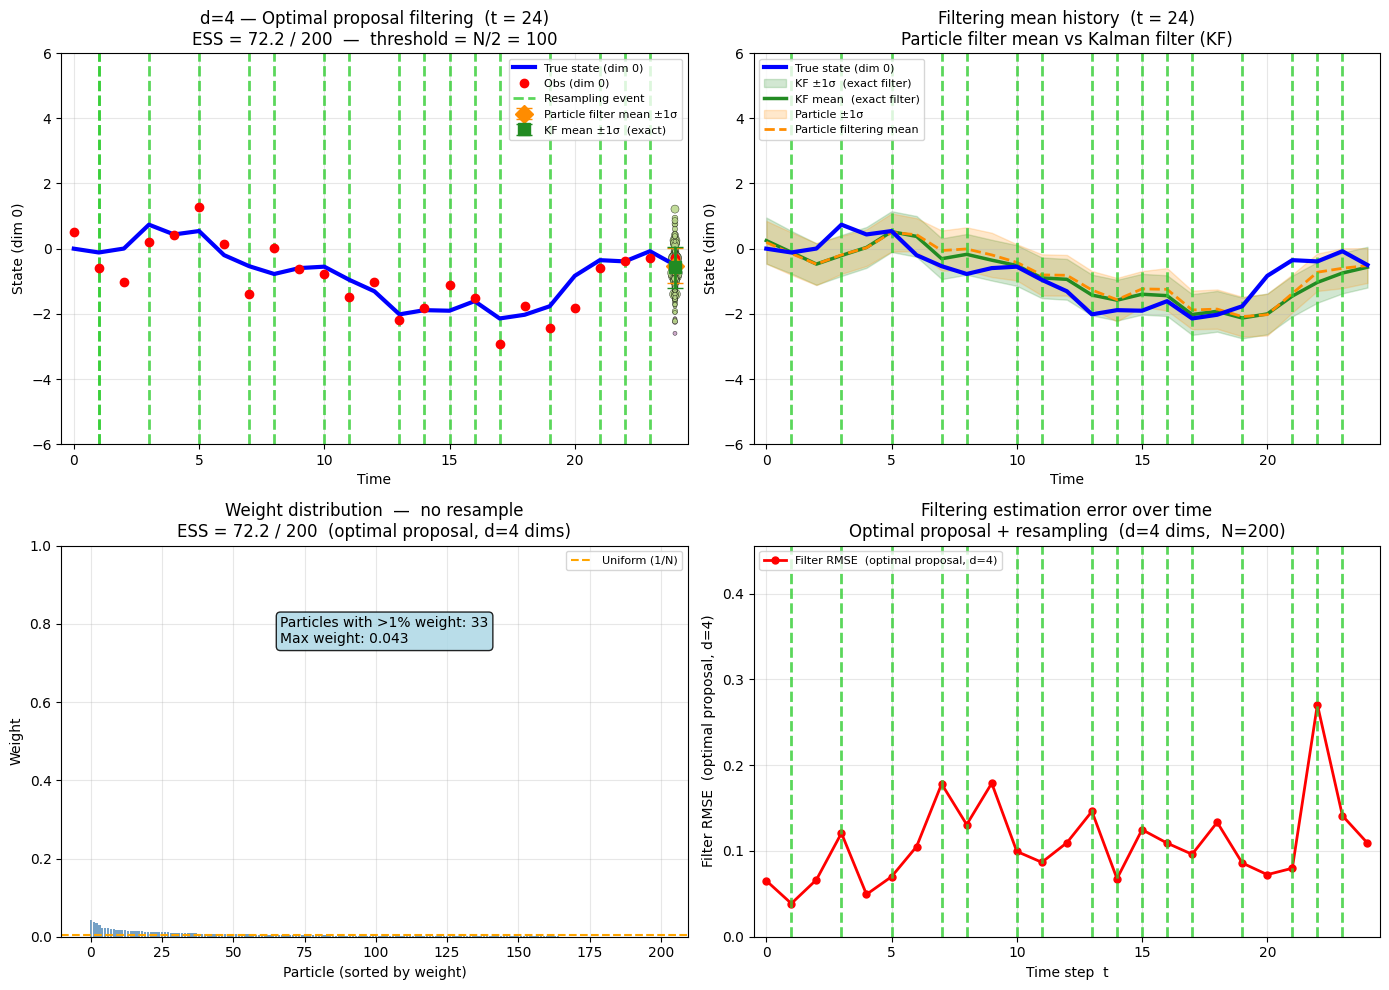


d=4, N=200: Resampling at timesteps: [1, 3, 5, 7, 8, 10, 11, 13, 14, 15, 16, 17, 19, 21, 22, 23]
Total resampling events: 16
Final ESS: 72.2 / 200


In [25]:
animate_high_dim_filtering_optimal(d = 4, plot_d = 0);

## Why Filtering Still Doesn't Remove the Curse of Dimensionality

Even after switching both examples to the **optimal proposal distribution**, the filtering distribution performs no better than the joint distribution in high dimension. The reason is still the same: the main difficulty comes from the **weight update**, not from whether we store the full trajectory or only the current state.

Both algorithms now run the same three steps per time step:

1. **Same optimal proposal:** $$q(x_t^{(i)} \mid x_{t-1}^{(i)}, y_t) = p(x_t \mid x_{t-1}^{(i)}, y_t) = \mathcal{N}\!\left(\mu_t^{(i)},\, \sigma_\text{opt}^2 I_d\right)$$
2. **Same incremental weight:** $$\tilde{w}_t^{(i)} \propto p(y_t \mid x_{t-1}^{(i)}) = \prod_{k=1}^{d} \mathcal{N}(y_t^k;\, x_{t-1}^{(i,k)},\, \sigma_\text{proc}^2 + \sigma_\text{obs}^2)$$
3. **Same resampling criterion:** ESS $< N/2$

So the filtering and joint versions still use **identical particle weights at the current time step**. That means they still suffer from the same high-dimensional likelihood collapse, independently of whether you later use those weights to summarise only $x_t$ (filtering) or the full trajectory $x_{0:t}$ (joint).

### What filtering *does* help with

Switching from joint to filtering estimation is still worthwhile, but for different reasons:

| | Filtering | Joint |
|---|---|---|
| Memory | $O(N \cdot d)$ | $O(N \cdot t \cdot d)$ |
| Path degeneracy | Not an issue | After many resamplings, most particles share ancestors → poor past-state estimates |
| Accuracy of current $x_t$ | Identical | Identical |

### What the optimal proposal *does* help with

The optimal proposal reduces weight variance compared to the prior proposal because it conditions on the current observation before proposing $x_t$:

$$q(x_t \mid x_{t-1}^{(i)}, y_t) = p(x_t \mid x_{t-1}^{(i)}, y_t) = \mathcal{N}\!\left(\mu_t^{(i)},\, \sigma_\text{opt}^2 I_d\right),$$

where 
$$\sigma_\text{opt}^{-2} = \sigma_\text{proc}^{-2} + \sigma_\text{obs}^{-2} \quad \text{and} \quad \mu_t^{(i)} = \sigma_\text{opt}^2\!\left(\frac{x_{t-1}^{(i)}}{\sigma_\text{proc}^2} + \frac{y_t}{\sigma_\text{obs}^2}\right).$$

This is the best single-step proposal for this linear-Gaussian model, and it clearly improves over the prior proposal. But it does **not** change the fact that in high dimension the incremental weights are still products over many coordinates, so the curse only slows rather than disappears. Addressing that more fully in very high dimensions requires stronger ideas such as SMC$^2$, tempering, localisation, or problem-specific structure.

---

# SMC² (Sequential Monte Carlo Squared)

The examples above assume the **model parameters** (e.g. $\sigma_\text{proc}$, $\sigma_\text{obs}$) are known. In practice they often are not, and naively running a separate particle filter for each candidate parameter value is intractable. SMC² handles **joint inference over states *and* parameters** in a single online pass through the data, by nesting two layers of SMC.

<div style="margin-left: 2em;">

**Outer layer — $\theta$-particles (parameter SMC):**  
Maintains $M$ samples $\theta^{(m)}$ from the parameter posterior $p(\theta \mid y_{1:t})$. These are weighted by the likelihood increment $p(y_t \mid y_{1:t-1}, \theta^{(m)})$ and resampled when the ESS collapses.

**Inner layer — $x$-particles (state particle filter):**  
For each $\theta$-particle $\theta^{(m)}$, a full particle filter with $N$ state particles estimates the likelihood that the outer layer needs but cannot compute analytically:

$$\hat{p}(y_t \mid y_{1:t-1}, \theta^{(m)}) \approx \frac{1}{N}\sum_{i=1}^N w_t^{(i,m)}$$
</div>

The total particle count at any time is $M \times N$.

Below we run an example of SMC2 using the same 1-d model as before, but now estimating both $\sigma_{proc}$ and $\sigma_{obs}$ in the outer loop. This needs to run longer than before to have sufficient observations to estimate these parameters.

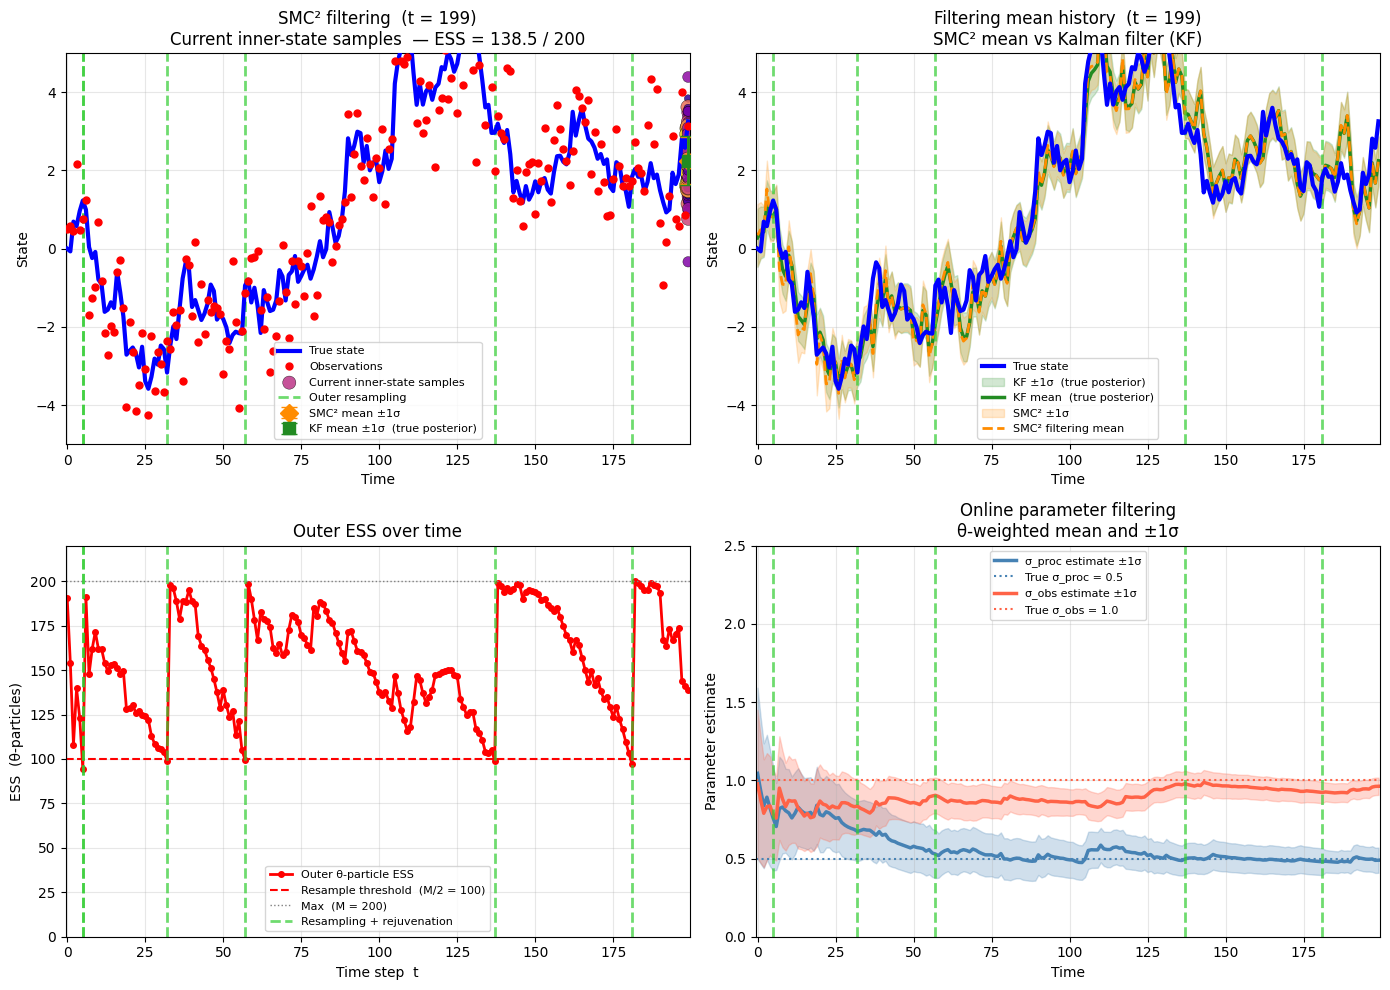


=== ANIMATED SMC² RESULTS ===
Final parameter estimates (θ-weighted mean ± std):
  σ_proc: 0.489 ± 0.081  (true: 0.5)
  σ_obs:  0.962 ± 0.055  (true: 1.0)
Outer resampling + rejuvenation events at t = [5, 32, 57, 137, 181]
Total rejuvenation events: 5


In [26]:
smc2_results = animate_smc2_filtering_demo();

SMC² is useful for estimating the filtering distribution but less so for estimating the joint distribution. For filtering $p(x_t, \theta \mid y_{1:t})$, the inner filter only tracks current particles $x_t^{(i,m)}$, discarding the past. Memory stays $O(M \times N \times d)$ regardless of $t$, and the outer likelihood estimates remain reliable throughout. For the joint distribution $p(x_{0:t}, \theta \mid y_{1:t})$, the inner filter must maintain the full particle lineage. Every resampling event inside the inner filter collapses ancestry — after $t$ steps, all $N$ state trajectories for a given $\theta^{(m)}$ may share a single ancestor at time 0. This path degeneracy degrades the smoothed estimates for early time steps and corrupts the outer likelihood estimates, causing the $\theta$-particle weights to deteriorate. To target the joint distribution properly requires even more computationally and memory intensive methods, such as **trajectory MCMC moves** during the SMC² rejuvenation step (e.g. Particle Gibbs or backward simulation), sometimes called **SMC² with particle MCMC moves**.

In [27]:
# End of notebook.